# Implementation tests

In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


project_root = Path.cwd().resolve().parents[1]
sys.path.append(str(project_root / "CODE" / "PaperCode"))

from factor_simulation import RiskFactorSimulator

import option_formulas

## Risk factor simulation

In [2]:


# Example inputs
num_risk_factors = 3
initial_spot_values = [100.0, 60.0, 140.0]
drift_array = [0.03, 0.03, 0.03]
volatility_array = [0.10, 0.25, 0.40]
correl_matrix = [
    [1.0, 0.80, 0.10],
    [0.80, 1.0, -0.5],
    [0.10, -0.5, 1.0],
]
# Irregular time grid is allowed
time_steps = np.linspace(0,10,50)
num_sims = 1000

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps
)

paths = simulator.simulate_paths(num_sims=num_sims)


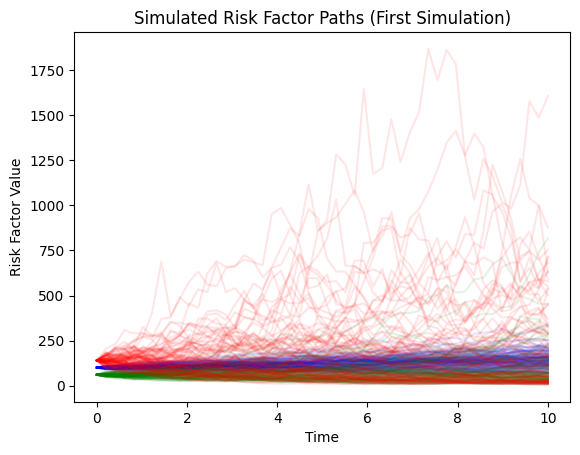

In [3]:
plt.plot(time_steps, paths[:100, :, 0].numpy().T, color='blue', alpha=0.1)
plt.plot(time_steps, paths[:100, :, 1].numpy().T, color='green', alpha=0.1)
plt.plot(time_steps, paths[:100, :, 2].numpy().T, color='red', alpha=0.1)
plt.title("Simulated Risk Factor Paths (First Simulation)")
plt.xlabel("Time")
plt.ylabel("Risk Factor Value")
plt.show()

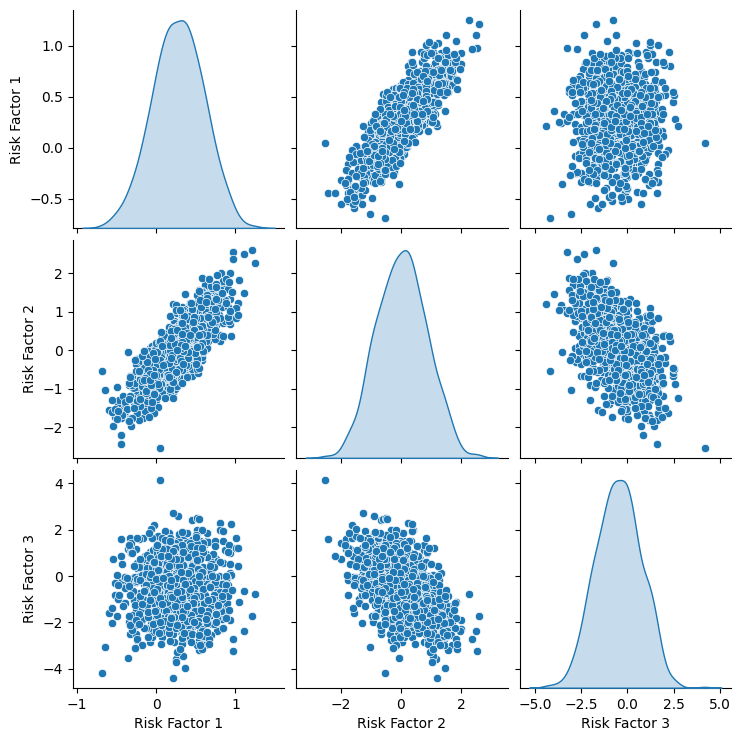

In [4]:
sns.pairplot(
    pd.DataFrame(np.log(paths[:,-1,:].numpy()/paths[:,0,:].numpy()), columns=[f"Risk Factor {i+1}" for i in range(num_risk_factors)]),
    diag_kind="kde")

## Volatility and correlation test

In [5]:
time_steps = [0.0, 0.5, 1.0, 2.5, 5.0, 7.5, 10.0, 15.0, 30.0]

corr_matrix = [[1.0, 0.80, 0.10],
               [0.80, 1.0, -0.5],
                [0.10, -0.5, 1.0]]

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps)

paths = simulator.simulate_paths(num_sims=30000)

for i in range(len(time_steps)-1):

    returns = np.log(paths[:,i+1,:].numpy()/paths[:,i,:].numpy())

    print("Volatilities at time step ", time_steps[i], ":", np.std(returns, axis=0)/np.sqrt(time_steps[i+1]-time_steps[i]))
    print("Correl matrix at time step ", time_steps[i], ":")
    print(np.corrcoef(returns.T))
    



Volatilities at time step  0.0 : [0.10038827 0.25065211 0.40132384]
Correl matrix at time step  0.0 :
[[ 1.          0.79896766  0.10403808]
 [ 0.79896766  1.         -0.49818854]
 [ 0.10403808 -0.49818854  1.        ]]
Volatilities at time step  0.5 : [0.09930633 0.24886458 0.39756727]
Correl matrix at time step  0.5 :
[[ 1.          0.80053801  0.09804166]
 [ 0.80053801  1.         -0.50069494]
 [ 0.09804166 -0.50069494  1.        ]]
Volatilities at time step  1.0 : [0.09948136 0.24799171 0.40104205]
Correl matrix at time step  1.0 :
[[ 1.          0.79681373  0.10829931]
 [ 0.79681373  1.         -0.49738653]
 [ 0.10829931 -0.49738653  1.        ]]
Volatilities at time step  2.5 : [0.1000407  0.2491409  0.39972733]
Correl matrix at time step  2.5 :
[[ 1.          0.80057429  0.10417192]
 [ 0.80057429  1.         -0.49554015]
 [ 0.10417192 -0.49554015  1.        ]]
Volatilities at time step  5.0 : [0.09968476 0.25018244 0.40017342]
Correl matrix at time step  5.0 :
[[ 1.          0.7

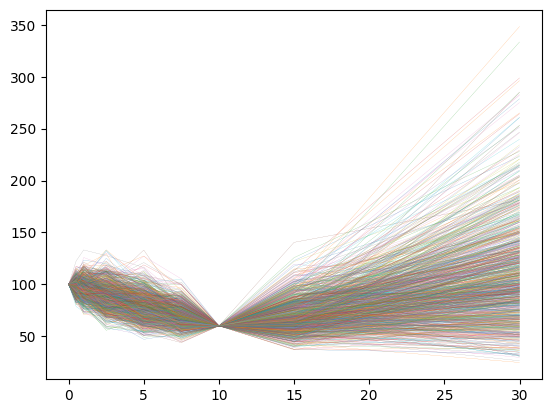

In [6]:
spot_t = [60,140,100]



brown_bridge_paths = simulator.simulate_paths_with_bridge(num_sims = 1000,
        pivot_step_idx = 6,
        spot_at_pivot= spot_t)


plt.plot(time_steps, brown_bridge_paths[:,:,0].T.detach(), linewidth = 0.1);



In [7]:

for i in range(len(time_steps)-1):

    returns = np.log(brown_bridge_paths[:,i+1,:].numpy()/brown_bridge_paths[:,i,:].numpy())

    print("Volatilities at time step ", time_steps[i], ":", np.std(returns, axis=0)/np.sqrt(time_steps[i+1]-time_steps[i]))
    print("Correl matrix at time step ", time_steps[i], ":")
    print(np.corrcoef(returns.T))

Volatilities at time step  0.0 : [0.0934232  0.23491395 0.39068089]
Correl matrix at time step  0.0 :
[[ 1.          0.78619158  0.12081057]
 [ 0.78619158  1.         -0.50148045]
 [ 0.12081057 -0.50148045  1.        ]]
Volatilities at time step  0.5 : [0.09900221 0.23691429 0.38108888]
Correl matrix at time step  0.5 :
[[ 1.          0.80189838  0.16025925]
 [ 0.80189838  1.         -0.44299443]
 [ 0.16025925 -0.44299443  1.        ]]
Volatilities at time step  1.0 : [0.09435491 0.23390448 0.36082503]
Correl matrix at time step  1.0 :
[[ 1.          0.81447083  0.09852867]
 [ 0.81447083  1.         -0.48000149]
 [ 0.09852867 -0.48000149  1.        ]]
Volatilities at time step  2.5 : [0.08681883 0.21702235 0.35117431]
Correl matrix at time step  2.5 :
[[ 1.          0.7988465   0.10667573]
 [ 0.7988465   1.         -0.49499568]
 [ 0.10667573 -0.49499568  1.        ]]
Volatilities at time step  5.0 : [0.08751465 0.22020739 0.35646291]
Correl matrix at time step  5.0 :
[[ 1.          0.7

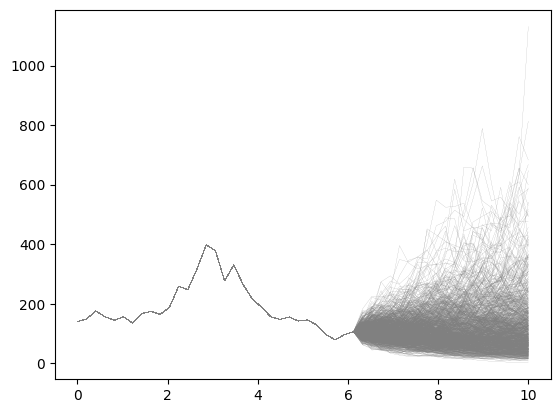

In [8]:
time_steps = np.linspace(0,10,50)


simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps)



upto_point_paths = simulator.simulate_same_path_up_do_date(num_sims = 1000,
        pivot_step_idx = 30)



plt.plot(time_steps, upto_point_paths[:,:,2].T.detach(), linewidth = 0.1, color = 'grey');

## Basket option formula

Simulation of risk factors

In [9]:
num_risk_factors = 3
initial_spot_values = [100.0, 60.0, 140.0]
drift_array = [0.03, 0.03, 0.03]
volatility_array = [0.10, 0.25, 0.40]
correl_matrix = [
    [1.0, 0.80, 0.10],
    [0.80, 1.0, -0.5],
    [0.10, -0.5, 1.0],
]
# Irregular time grid is allowed
time_steps = np.linspace(0,5,21)
num_sims = 1000

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps)

paths = simulator.simulate_paths(500)

In [10]:
paths[0]


tensor([[100.0000,  60.0000, 140.0000],
        [ 97.9656,  61.2322, 109.3184],
        [101.8725,  63.1696, 113.1978],
        [109.4331,  76.4938,  91.9638],
        [112.2014,  75.8735, 103.4993],
        [119.1020,  84.2834, 112.2198],
        [122.7713,  90.5849, 108.6808],
        [117.7471,  81.2087, 103.2817],
        [123.5406,  87.5145, 114.0710],
        [128.3754,  85.6819, 149.3629],
        [130.0724,  79.1202, 187.8009],
        [130.1767,  76.9367, 191.2680],
        [133.8564,  81.9922, 173.4151],
        [135.0146,  83.3984, 180.4411],
        [140.7193,  98.5822, 141.4839],
        [150.9100, 105.9581, 168.5098],
        [150.1066, 102.9023, 178.3188],
        [145.7847, 107.2224, 127.2464],
        [142.9603,  98.2337, 138.4732],
        [142.3525,  88.9752, 174.4360],
        [144.4403,  96.9584, 133.7874]], dtype=torch.float64)

In [11]:

basket_result = option_formulas.basket_geom_asian(init_time_array= torch.tensor(time_steps),
                                                value_date_index= 0, risk_free_rate= 0.03, num_assets= 3,
                                                 assets_vol= torch.tensor(volatility_array),
                                                 assets_correl= torch.tensor(corr_matrix), 
                                                 price_history=paths[0].T, IsCall= True)

basket_result

tensor(0.0628, dtype=torch.float64)

In [12]:
basket_result.numpy()

array(0.06275227)

## Check: scalar vs vectorized basket geometric Asian

This cell compares the scalar and vectorized implementations using the RNN-style path layout `(simulations, time, assets)`.


In [30]:
from option_formulas import basket_geom_asian, basket_geom_asian_vectorized
import torch


init_time_array = torch.as_tensor(time_steps, dtype=torch.float64)
n_assets = int(num_risk_factors)
n_times = len(init_time_array)

# Simulation output is RNN-style: (simulations, time, assets).
price_history = torch.as_tensor(paths, dtype=torch.float64)


risk_free_rate_t = torch.as_tensor(0.03, dtype=torch.float64)
volatility_t = torch.as_tensor(volatility_array, dtype=torch.float64)
correl_t = torch.as_tensor(corr_matrix, dtype=torch.float64)

vec_full = basket_geom_asian_vectorized(
    init_time_array=init_time_array,
    risk_free_rate=risk_free_rate_t,
    num_assets=n_assets,
    assets_vol=volatility_t,
    assets_correl=correl_t,
    price_history=price_history,
    IsCall=True,
)

# Compare only non-terminal dates to avoid scalar maturity edge-case.
vec_values = vec_full[:, :-1, :]

# Force identical dimensions: (simulations, time-1, 1)
scalar_values = torch.empty_like(vec_values)
for sim_index in range(price_history.shape[0]):
    for value_date_index in range(n_times - 1):
        scalar_values[sim_index, value_date_index, 0] = basket_geom_asian(
            init_time_array=init_time_array,
            value_date_index=value_date_index,
            risk_free_rate=risk_free_rate_t,
            num_assets=n_assets,
            assets_vol=volatility_t,
            assets_correl=correl_t,
            price_history=price_history[sim_index].T,
            IsCall=True,
        )

abs_diff = torch.abs(vec_values - scalar_values)

print(f"paths shape:        {tuple(price_history.shape)}")
print(f"vectorized shape:   {tuple(vec_values.shape)}")
print(f"scalar shape:       {tuple(scalar_values.shape)}")
print(f"max abs diff:       {abs_diff.max().item():.3e}")
print(f"mean abs diff:      {abs_diff.mean().item():.3e}")
assert torch.allclose(vec_values, scalar_values, rtol=1e-10, atol=1e-10)


paths shape:        (500, 21, 3)
vectorized shape:   (500, 20, 1)
scalar shape:       (500, 20, 1)
max abs diff:       5.135e-16
mean abs diff:      1.267e-17


IndexError: too many indices for tensor of dimension 2

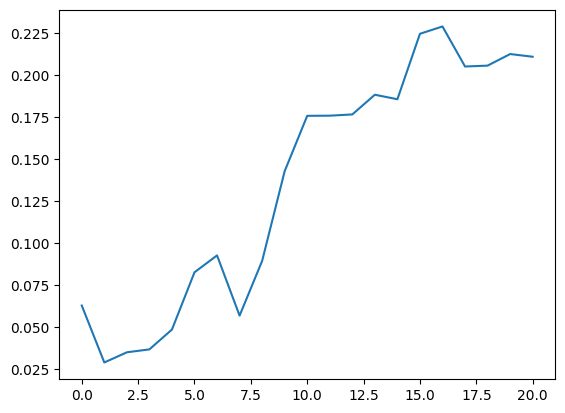

In [26]:
plt.plot(vec_values[0,:,0])
plt.plot(scalar_values[0,:,0])


In [27]:
scalar_values.shape

torch.Size([500, 20])

In [28]:
vec_values.shape

torch.Size([500, 21, 1])

## Check: discounted cash-flow stream

This cell checks that the realized cash-flow generator returns an RNN-style stream and that its Monte Carlo average is consistent with the analytic time-zero price.


In [ ]:
from CODE.PaperCode.cashflows import basket_geom_asian_cashflows


cashflows = basket_geom_asian_cashflows(
    init_time_array=init_time_array,
    risk_free_rate=risk_free_rate_t,
    num_assets=n_assets,
    price_history=price_history,
    IsCall=True,
)

analytic_t0 = vec_values[:, 0, 0].mean()
mc_t0 = cashflows[:, -1, 0].mean()
abs_diff = torch.abs(mc_t0 - analytic_t0)
std_error = cashflows[:, -1, 0].std(unbiased=True) / torch.sqrt(
    torch.as_tensor(cashflows.shape[0], dtype=torch.float64)
)
confidence_level = 0.95
z_score = torch.as_tensor(1.959963984540054, dtype=torch.float64)
ci_low = mc_t0 - z_score * std_error
ci_high = mc_t0 + z_score * std_error
analytic_in_ci = (ci_low <= analytic_t0) & (analytic_t0 <= ci_high)

print(f"cashflows shape:       {tuple(cashflows.shape)}")
print(f"non-terminal abs sum:  {cashflows[:, :-1, :].abs().sum().item():.3e}")
print(f"MC discounted payoff:  {mc_t0.item():.10f}")
print(f"analytic t0 price:     {analytic_t0.item():.10f}")
print(f"abs diff:              {abs_diff.item():.3e}")
print(f"MC standard error:     {std_error.item():.3e}")
print(f"{confidence_level:.0%} MC CI:             [{ci_low.item():.10f}, {ci_high.item():.10f}]")
print(f"analytic inside CI:    {bool(analytic_in_ci)}")

assert cashflows.shape == (price_history.shape[0], price_history.shape[1], 1)
assert torch.allclose(cashflows[:, :-1, :], torch.zeros_like(cashflows[:, :-1, :]))
assert abs_diff < 4.0 * std_error
assert analytic_in_ci
